# Try modeling the SEDs just as a single power-law decline

We really don't have much data so let's see how these do

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

import json

from corner import corner

from otter import Otter

from scipy.optimize import curve_fit

def linear_model(log_freq, alpha, b):
    return alpha*log_freq + b

In [18]:
def choose_sideband_fullband(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def make_sed(tde_name, ax=None, filter_sidebands=True):
    classes = private_data.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]
    if filter_sidebands:
        df = choose_sideband_fullband(df)

    if ax is not None:
        for label, grp in df.groupby('converted_date'):
            
            ax.errorbar(
                grp.converted_freq, 
                grp.converted_flux,
                fmt='o',
                markersize=3,
                yerr=grp.converted_flux_err,
                label=f'{label:.2f} MJD',
                uplims=grp.upperlimit
            )
    
            # next(ax._get_lines.prop_cycler)['color']
    
    
        ax.set_ylabel('Flux [Jy]')
        ax.set_xlabel('Frequency [GHz]')
        ax.set_yscale('log')
    
        at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
        ax.add_artist(at)
    
        ax.legend(fontsize=12)
    
    return df

In [19]:
otterpath = os.path.join(os.getcwd(), "private_otter_data")
overwrite = False

radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

if overwrite:

    wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
    
    wise_phot["date"] = wise_phot["date_mjd"]
    wise_phot["date_format"] = "mjd"
    wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]
    
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(
        url="http://localhost:8529",
        username="user-guest",
        password="",
        datadir=otterpath,
        gen_summary=True
    )

radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz"
)

/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:624: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:624: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:624: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:624: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping b

/home/noahf/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(0.4620869604990106, 296.8847694113367)
(0.3080567277176454, 134.48725000082226)
(0.02415350341549743, 159.77197107445892)
(0.3585544786731519, 21.612552922036496)
(0.17492800350686283, 211.08693554315758)


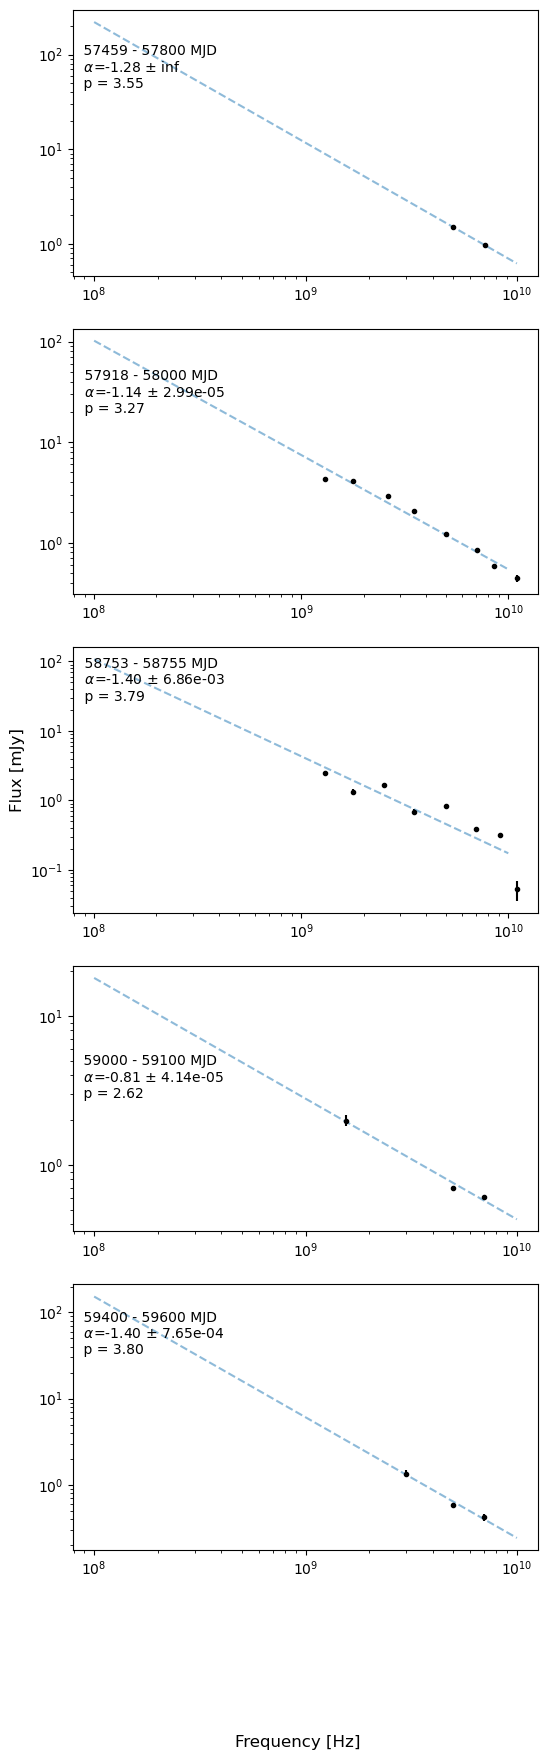

In [77]:
df = make_sed("SDSS_J1241")

date_ranges = [
    # (50506, 50507),
    (57459, 57800), 
    (57918, 58000),
    # (58580, 58590),
    (58753, 58755),
    (59000, 59100),
    (59400, 59600)
]

def chi2_fit(df, date_ranges, targ="SDSSJ1241"):
    n = len(date_ranges)
    fig, axs = plt.subplots(n,1, figsize=(6,4*n))
    for r, ax in zip(date_ranges, axs):
        data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
        ax.errorbar(
            data.converted_freq*1e9, 
            data.converted_flux,
            fmt='o',
            markersize=3,
            yerr=data.converted_flux_err,
            label=f'{r[0]} - {r[1]} MJD',
            uplims=data.upperlimit,
            color='k'
        )
        
        ax.set_yscale("log")
        ax.set_xscale("log")

        vars, cov = curve_fit(linear_model, np.log10(data.converted_freq*1e9), np.log10(data.converted_flux))
        err = np.diag(cov)**2
        alpha, alpha_err = vars[0], err[0]

        xfit = np.logspace(8, 10)
        yfit = linear_model(np.log10(xfit), *vars)
        ax.plot(xfit, 10**yfit, linestyle='--', alpha=0.5)

        print(ax.get_ylim())
        ax.text(
            5e7,
            sum(ax.get_ylim())/10,
            rf"""
            {r[0]} - {r[1]} MJD
            $\alpha$={alpha:.2f} $\pm$ {alpha_err:.2e}
            p = {1-2*alpha:.2f}
            """,
        )

        
    fig.supylabel("Flux [mJy]")
    fig.supxlabel("Frequency [Hz]")
    fig.savefig(f"{targ}-radio-simple-fit.png")

chi2_fit(df, date_ranges)

/home/noahf/astro-otter/otter/src/otter/io/transient.py:866: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(0.057329857385034697, 5.17630617293902)
(0.020496706707923407, 1.7678933045727903)


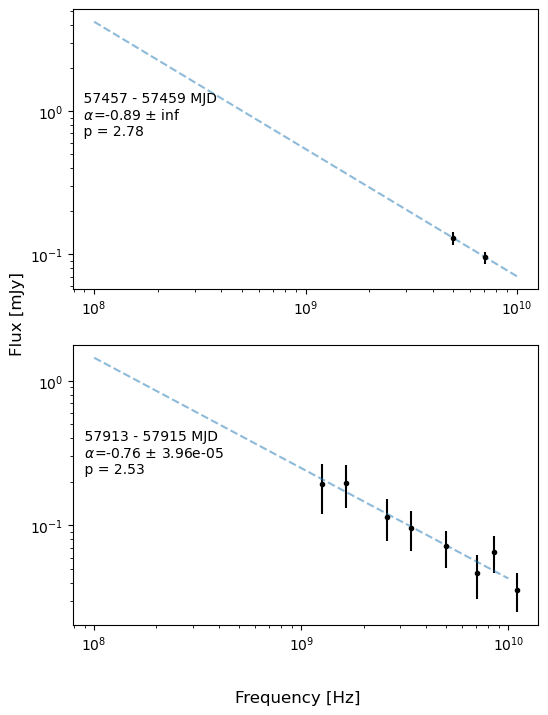

In [78]:
date_ranges = [
    (57457, 57459),
    (57913, 57915)
]

df = make_sed("SDSS_J0748")

chi2_fit(df, date_ranges, targ="SDSSJ0748")

/home/noahf/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(0.39910748160820836, 99.88451312684644)
(0.19555576219482523, 67.17396854641544)


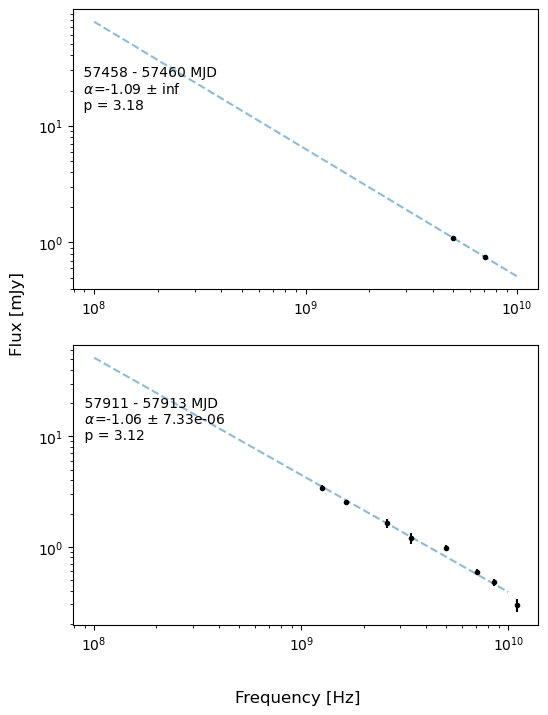

In [79]:
df = make_sed("SDSS_J0938")

date_ranges = [
    (57458, 57460),
    (57911, 57913)
]

chi2_fit(df, date_ranges, targ="SDSSJ0938")